<a href="https://colab.research.google.com/github/SNCA-24/llm-distractor-ranking-comparison/blob/encoder-decoder/LLM_Distractor_Ranking_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Part 2 - Evaluation and Reporting

In [1]:
# -*- coding: utf-8 -*-
"""NLP - Final Part 2 - Evaluation and Reporting"""

import glob
import os
import re
import ast
import logging
import warnings
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import cohen_kappa_score

In [2]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Common configuration
OUTPUT_DIR = os.path.join(os.getcwd(), 'nlp_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Locate and load CSVs
def load_predictions(pattern: str = 'predictions_*.csv') -> pd.DataFrame:
    """Load and combine prediction CSV files."""
    files = glob.glob(pattern)
    if not files:
        raise FileNotFoundError(f"No files matching '{pattern}'")

    required_columns = {'model_name', 'variant', 'question', 'predicted_choice', 'correct_choice'}
    dfs = []

    for fp in files:
        df = pd.read_csv(fp)
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"File {os.path.basename(fp)} missing columns: {missing}")
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)
    logging.info(f"Combined dataframe shape: {combined_df.shape}")
    return combined_df

# Load data
try:
    combined_df = load_predictions()
    human_ranked_df = pd.read_csv('human_ranked.csv')
    combined_df.to_csv(os.path.join(OUTPUT_DIR, 'combined_predictions.csv'), index=False)
except Exception as e:
    logging.error(f"Error loading data: {str(e)}")
    raise



In [3]:
# Cell 2 – Revised Tie-Case Detection & Subset Creation

def create_subsets(combined_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create subsets of the data based on prediction correctness and tie cases.

    Returns:
        Tuple containing:
        - correct_df: Correct predictions
        - tie_df: Tie case predictions
        - valid_df: Valid distractor predictions
        - model_triplets_df: Generated model triplets
    """
    # 1) Correct predictions
    correct_df = combined_df[combined_df.predicted_choice == combined_df.correct_choice]
    logging.info(f"Subset 1 (Correct predictions): {correct_df.shape[0]} rows")

    # 2) Incorrect predictions
    incorrect_df = combined_df[combined_df.predicted_choice != combined_df.correct_choice].copy()
    logging.info(f"Total incorrect predictions: {incorrect_df.shape[0]} rows")

    # 3) Identify tie-case vs valid questions
    tie_questions = []
    valid_questions = []
    for q, grp in incorrect_df.groupby('question'):
        freq = grp['predicted_choice'].value_counts()
        # Tie if fewer than 3 distinct distractors OR any vote-count duplicates
        if len(freq) < 3 or freq.nunique() < len(freq):
            tie_questions.append(q)
        else:
            valid_questions.append(q)

    # 4) Build DataFrames
    tie_df = incorrect_df[incorrect_df['question'].isin(tie_questions)].copy()
    valid_df = incorrect_df[incorrect_df['question'].isin(valid_questions)].copy()

    logging.info(f"Subset 2 (Tie-case questions): {tie_df.shape[0]} rows, {tie_df['question'].nunique()} questions")
    logging.info(f"Subset 3 (Valid distractor questions): {valid_df.shape[0]} rows, {valid_df['question'].nunique()} questions")

    # 5) Generate ensemble triplets only for valid questions
    triplet_records = []
    for q in valid_questions:
        grp = incorrect_df[incorrect_df['question'] == q]
        freq = grp['predicted_choice'].value_counts()
        trip = get_triplet(freq)
        triplet_records.append({'question': q, 'model_triplet': trip})

    model_triplets_df = pd.DataFrame(triplet_records)
    logging.info(f"Generated {len(model_triplets_df)} valid triplets")

    # 6) Save subsets
    for name, df in [
        ('correct_predictions.csv', correct_df),
        ('tie_predictions.csv', tie_df),
        ('valid_predictions.csv', valid_df),
        ('model_triplets.csv', model_triplets_df)
    ]:
        df.to_csv(os.path.join(OUTPUT_DIR, name), index=False)

    logging.info("✅ Subset creation complete")
    return correct_df, tie_df, valid_df, model_triplets_df

def get_triplet(freq_series: pd.Series) -> List[str]:
    """
    Return the 3 distractors sorted by descending vote count,
    with deterministic tie-breaking by distractor label.
    """
    sorted_v = freq_series.sort_index().sort_values(ascending=False)
    return sorted_v.index.tolist()[:3]

# Create subsets
correct_df, tie_df, valid_df, model_triplets_df = create_subsets(combined_df)



In [4]:
# Cell 3 - Metric Definition

def clean_q(q: str) -> str:
    """Clean and normalize question text."""
    if isinstance(q, tuple):
        q = q[0]
    if isinstance(q, str) and q.startswith("(") and q.endswith("',)"):
        try:
            q = ast.literal_eval(q)[0]
        except:
            pass
    q = str(q).strip().lower()
    q = re.sub(r'\s+', ' ', q)
    q = q.replace('"','"').replace('"','"').replace('—','-').replace('–','-')
    return q

def parse_ranking_string(ranking_str: str) -> List[int]:
    """Parse a comma-separated string of rankings into a list of integers."""
    if not ranking_str or not isinstance(ranking_str, str):
        return []

    try:
        tokens = [p.strip() for p in ranking_str.split(',') if p.strip() != ""]
        ints = []
        for tok in tokens:
            try:
                ints.append(int(tok))
            except ValueError:
                continue

        if len(ints) == 3:
            return ints
        if len(ints) >= 4:
            return ints[1:4]  # Take first three after index
        return []

    except Exception as e:
        logging.warning(f"Error parsing ranking string '{ranking_str}': {str(e)}")
        return []

def calculate_pairwise_concordance(r1: List[int], r2: List[int]) -> float:
    """Calculate the pairwise concordance rate between two rankings."""
    if not r1 or not r2 or len(r1) != len(r2):
        return 0.0

    concordant = 0
    total_pairs = 0
    m = len(r1)

    for i in range(m):
        for j in range(i + 1, m):
            if (r1[i] - r1[j]) * (r2[i] - r2[j]) > 0:
                concordant += 1
            total_pairs += 1

    return concordant / total_pairs if total_pairs > 0 else 0.0

def calculate_top_k_accuracy(r1: List[int], r2: List[int], k: int = 1) -> bool:
    """Calculate if the top k items match between two rankings."""
    if len(r1) < k or len(r2) < k:
        return False

    top_k_r1 = sorted(range(len(r1)), key=lambda x: r1[x])[:k]
    top_k_r2 = sorted(range(len(r2)), key=lambda x: r2[x])[:k]

    return set(top_k_r1) == set(top_k_r2)

def calculate_weighted_kappa(r1: List[int], r2: List[int]) -> float:
    """Calculate weighted Cohen's kappa between two rankings."""
    try:
        labels = sorted(set(r1 + r2))
        r1_cat = [labels.index(x) for x in r1]
        r2_cat = [labels.index(x) for x in r2]
        return cohen_kappa_score(r1_cat, r2_cat, weights='quadratic')
    except Exception as e:
        logging.warning(f"Error calculating weighted kappa: {str(e)}")
        return 0.0

def calculate_metrics(r1: List[int], r2: List[int]) -> Dict[str, float]:
    """Calculate all metrics for a pair of rankings."""
    try:
        if not r1 or not r2 or len(r1) != len(r2):
            return {
                'exact_match': 0,
                'spearman_rho': 0.0,
                'spearman_p': 1.0,
                'kendall_tau': 0.0,
                'kendall_p': 1.0,
                'pairwise_concordance': 0.0,
                'weighted_kappa': 0.0,
                'top1_accuracy': 0,
                'top2_accuracy': 0,
                'tie_cases': 0
            }

        # Calculate correlation metrics
        spearman = spearmanr(r1, r2)
        kendall = kendalltau(r1, r2)

        metrics = {
            'exact_match': int(r1 == r2),
            'spearman_rho': float(spearman.statistic) if not np.isnan(spearman.statistic) else 0.0,
            'spearman_p': float(spearman.pvalue) if not np.isnan(spearman.pvalue) else 1.0,
            'kendall_tau': float(kendall.statistic) if not np.isnan(kendall.statistic) else 0.0,
            'kendall_p': float(kendall.pvalue) if not np.isnan(kendall.pvalue) else 1.0,
            'pairwise_concordance': calculate_pairwise_concordance(r1, r2),
            'weighted_kappa': calculate_weighted_kappa(r1, r2),
            'top1_accuracy': calculate_top_k_accuracy(r1, r2, 1),
            'top2_accuracy': calculate_top_k_accuracy(r1, r2, 2),
            'tie_cases': int(len(set(r1)) < len(r1) or len(set(r2)) < len(r2))
        }
        return metrics
    except Exception as e:
        logging.error(f"Error calculating metrics: {str(e)}")
        return {
            'exact_match': 0,
            'spearman_rho': 0.0,
            'spearman_p': 1.0,
            'kendall_tau': 0.0,
            'kendall_p': 1.0,
            'pairwise_concordance': 0.0,
            'weighted_kappa': 0.0,
            'top1_accuracy': 0,
            'top2_accuracy': 0,
            'tie_cases': 0
        }

def aggregate_metrics(metrics_list: List[Dict[str, float]], n_items: int) -> Dict[str, float]:
    """Aggregate metrics across multiple comparisons."""
    if not metrics_list or n_items <= 0:
        return {
            'exact_match_pct': 0.0,
            'avg_spearman_rho': 0.0,
            'avg_spearman_p': 1.0,
            'avg_kendall_tau': 0.0,
            'avg_kendall_p': 1.0,
            'avg_pairwise_concordance': 0.0,
            'avg_weighted_kappa': 0.0,
            'top1_accuracy': 0.0,
            'top2_accuracy': 0.0,
            'tie_cases': 0,
            'tie_case_pct': 0.0
        }

    aggregated = {
        'exact_match_pct': (sum(m['exact_match'] for m in metrics_list) / n_items) * 100,
        'avg_spearman_rho': np.nanmean([m['spearman_rho'] for m in metrics_list]),
        'avg_spearman_p': np.nanmean([m['spearman_p'] for m in metrics_list]),
        'avg_kendall_tau': np.nanmean([m['kendall_tau'] for m in metrics_list]),
        'avg_kendall_p': np.nanmean([m['kendall_p'] for m in metrics_list]),
        'avg_pairwise_concordance': (np.nanmean([m['pairwise_concordance'] for m in metrics_list])) * 100,
        'avg_weighted_kappa': np.nanmean([m['weighted_kappa'] for m in metrics_list]),
        'top1_accuracy': (sum(m['top1_accuracy'] for m in metrics_list) / n_items) * 100,
        'top2_accuracy': (sum(m['top2_accuracy'] for m in metrics_list) / n_items) * 100,
        'tie_cases': sum(m['tie_cases'] for m in metrics_list),
        'tie_case_pct': (sum(m['tie_cases'] for m in metrics_list) / n_items) * 100
    }
    return aggregated



def print_metrics(metrics: Dict[str, float], prefix: str = "") -> None:
    """Print metrics in a formatted way."""
    # —— Normalize any one-off keys into the agg‐style names ——
    if 'spearman_rho' in metrics:
        metrics['avg_spearman_rho'] = metrics.pop('spearman_rho')
    if 'spearman_p' in metrics:
        metrics['avg_spearman_p'] = metrics.pop('spearman_p')
    if 'kendall_tau' in metrics:
        metrics['avg_kendall_tau'] = metrics.pop('kendall_tau')
    if 'kendall_p' in metrics:
        metrics['avg_kendall_p'] = metrics.pop('kendall_p')
    # ——————————————————————————————

    if not metrics:
        logging.warning("No metrics to print")
        return

    print(f"\n{prefix}Metrics:")
    print(f"  Exact-match:         {metrics.get('exact_match_pct', 0.0):.2f}%")
    print(f"  Spearman's ρ:        {metrics.get('avg_spearman_rho', 0.0):.3f} (p={metrics.get('avg_spearman_p', 1.0):.3f})")
    print(f"  Kendall's τ:         {metrics.get('avg_kendall_tau', 0.0):.3f} (p={metrics.get('avg_kendall_p', 1.0):.3f})")
    print(f"  Pairwise concordance: {metrics.get('avg_pairwise_concordance', 0.0):.2f}%")
    print(f"  Weighted Cohen's κ:  {metrics.get('avg_weighted_kappa', 0.0):.3f}")
    print(f"  Top-1 accuracy:      {metrics.get('top1_accuracy', 0.0):.2f}%")
    print(f"  Top-2 accuracy:      {metrics.get('top2_accuracy', 0.0):.2f}%")

    # raw tie-case count (if available)
    if 'tie_cases' in metrics:
        print(f"  Tie cases:           {int(metrics['tie_cases'])}")

    # tie-case percentage (if available)
    if 'tie_case_pct' in metrics:
        print(f"  Tie case percentage: {metrics['tie_case_pct']:.2f}%")
    else:
        # method-specific fallback
        for m in ['method1_', 'method2_']:
            key = f'{m}tie_case_pct'
            if key in metrics:
                print(f"  Tie case percentage: {metrics[key]:.2f}%")
                break




In [5]:
# Cell 4 - Inter-Annotator Agreement (IAA) Calculation
def calculate_iaa(human_ranked_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate comprehensive inter-annotator agreement metrics.

    Args:
        human_ranked_df: DataFrame containing human annotations

    Returns:
        DataFrame containing IAA metrics
    """
    # Select overlapping questions
    overlap_df = human_ranked_df.dropna(
        subset=[
            'distractor_ranking_best_to_worst_Annotator_1',
            'distractor_ranking_best_to_worst_Annotator_2'
        ]
    ).copy()

    n_items = len(overlap_df)
    if n_items == 0:
        raise ValueError("No overlapping annotations found for IAA calculation.")

    # Calculate metrics for each question
    metrics_list = []
    for _, row in overlap_df.iterrows():
        r1 = parse_ranking_string(row['distractor_ranking_best_to_worst_Annotator_1'])
        r2 = parse_ranking_string(row['distractor_ranking_best_to_worst_Annotator_2'])

        if not r1 or not r2:
            continue

        metrics_list.append(calculate_metrics(r1, r2))

    # Aggregate metrics
    results = aggregate_metrics(metrics_list, n_items)
    results['n_overlapping'] = n_items

    print("\n" + "="*80)
    print("IAA Calculation (Human-Human)")
    print("="*80)


    # Print results
    logging.info(f"\nInter-Annotator Agreement Results (n={n_items} questions):")
    print_metrics(results, prefix="  ")

    # Save results
    iaa_results_df = pd.DataFrame([results])
    iaa_results_df.to_csv(os.path.join(OUTPUT_DIR, 'iaa_results.csv'), index=False)
    logging.info(f"✅ IAA results saved to {os.path.join(OUTPUT_DIR, 'iaa_results.csv')}")

    return iaa_results_df

# Calculate IAA metrics
iaa_metrics = calculate_iaa(human_ranked_df)





IAA Calculation (Human-Human)

  Metrics:
  Exact-match:         20.63%
  Spearman's ρ:        0.087 (p=0.413)
  Kendall's τ:         0.069 (p=0.746)
  Pairwise concordance: 53.44%
  Weighted Cohen's κ:  0.088
  Top-1 accuracy:      42.86%
  Top-2 accuracy:      34.92%
  Tie cases:           0
  Tie case percentage: 0.00%


In [6]:
# Cell 5 - Method 1 Evaluation
def evaluate_method1(model_triplets_df: pd.DataFrame,
                    human_ranked_df: pd.DataFrame) -> pd.DataFrame:
    """
    Evaluate Method 1 (apple-to-apple comparison) with comprehensive metrics.

    Args:
        model_triplets_df: DataFrame containing model triplets
        human_ranked_df: DataFrame containing human annotations

    Returns:
        DataFrame containing Method 1 evaluation results
    """
    print("\n" + "="*80)
    print("METHOD 1 EVALUATION (Overlapping Questions)")
    print("="*80)

    # 1) Build the overlap_df
    overlap = human_ranked_df.dropna(
        subset=[
            'distractor_ranking_best_to_worst_Annotator_1',
            'distractor_ranking_best_to_worst_Annotator_2'
        ]
    ).copy()
    human_n_full = len(overlap)

    # 2) Parse both annotators
    overlap['h1'] = overlap['distractor_ranking_best_to_worst_Annotator_1'].apply(parse_ranking_string)
    overlap['h2'] = overlap['distractor_ranking_best_to_worst_Annotator_2'].apply(parse_ranking_string)

    # 3) Clean & normalize questions
    overlap['q_norm'] = overlap['question'].apply(clean_q)
    mt = model_triplets_df.copy()
    mt['q_norm'] = mt['question'].apply(clean_q)

    # 4) Merge on normalized questions (left so we can count missing triplets)
    merged = pd.merge(
        overlap[['q_norm', 'h1', 'h2']],
        mt[['q_norm', 'model_triplet']],
        on='q_norm', how='left'
    )

    # Count true ensemble tie-cases (missing or invalid triplet)
    tie_cases = merged['model_triplet'].isna().sum()

    # **NEW**: list out the questions that are being treated as tie-cases
    tie_questions = merged.loc[merged['model_triplet'].isna(), 'q_norm'].tolist()
    print(f"\n  Tie cases ({tie_cases} total):")
    for q in tie_questions:
        print(f"    – {q}")

    # Keep only fully-valid rows
    merged = merged[
        merged['h1'].apply(lambda x: isinstance(x, list) and len(x) == 3) &
        merged['h2'].apply(lambda x: isinstance(x, list) and len(x) == 3) &
        merged['model_triplet'].apply(lambda x: isinstance(x, list) and len(x) == 3)
    ].copy()
    eval_n = len(merged)

    # 5) Calculate metrics for each question
    hh_metrics_list = []
    mh_metrics_list = []
    for _, row in merged.iterrows():
        h1, h2, model = row['h1'], row['h2'], row['model_triplet']
        hh_metrics_list.append(calculate_metrics(h1, h2))
        mh_metrics_list.append(calculate_metrics(model, h1))

    # 6) Aggregate
    hh_agg = aggregate_metrics(hh_metrics_list, eval_n)
    mh_agg = aggregate_metrics(mh_metrics_list, eval_n)

    # Build results, preserving the metric names correctly
    results = {
        'human_n_full': human_n_full,
        'eval_n': eval_n,
        # Human-Human metrics
        **{f'hh_{k}': v for k, v in hh_agg.items()},
        # Model-Human metrics
        'method1_exact_match_pct': mh_agg['exact_match_pct'],
        'method1_pairwise_concordance': mh_agg['avg_pairwise_concordance'],
        'method1_top1_accuracy': mh_agg['top1_accuracy'],
        'method1_top2_accuracy': mh_agg['top2_accuracy'],
        'method1_spearman_rho': mh_agg['avg_spearman_rho'],
        'method1_kendall_tau': mh_agg['avg_kendall_tau'],
        'method1_spearman_p':   mh_agg['avg_spearman_p'],
        'method1_kendall_p':    mh_agg['avg_kendall_p'],
        'method1_weighted_kappa': mh_agg['avg_weighted_kappa'],
        # Tie case metrics
        'method1_tie_case': tie_cases,
        'method1_tie_case_pct': (tie_cases / human_n_full) * 100
    }

    # Log results
    logging.info(f"\nMethod 1 Evaluation Results (n={eval_n}/{human_n_full} questions):")
    logging.info("\nHuman-Human Agreement:")
    print_metrics({k[3:]: v for k, v in results.items() if k.startswith('hh_')})
    logging.info("\nModel-Human Agreement:")
    print_metrics({k[8:]: v for k, v in results.items() if k.startswith('method1_')})

    # Save results
    results_df = pd.DataFrame([results])
    out_path = os.path.join(OUTPUT_DIR, 'method1_results.csv')
    results_df.to_csv(out_path, index=False)
    logging.info(f"✅ Method 1 results saved to {out_path}")

    return results_df

# Evaluate Method 1
method1_results_df = evaluate_method1(model_triplets_df, human_ranked_df)







METHOD 1 EVALUATION (Overlapping Questions)

  Tie cases (6 total):
    – which of the following countries had the highest average number of years of schooling in 2020?
    – in 2020, which region had the highest number of forcibly displaced people?
    – which of the following sorting algorithms is not stable?
    – which of the following logics cannot be expressed using propositional logic?
    – which of the following is a biotic factor that could affect the growth rate of a population?
    – the molecule with a tetrahedral shape is

Metrics:
  Exact-match:         21.05%
  Spearman's ρ:        0.140 (p=0.421)
  Kendall's τ:         0.111 (p=0.754)
  Pairwise concordance: 55.56%
  Weighted Cohen's κ:  0.142
  Top-1 accuracy:      45.61%
  Top-2 accuracy:      36.84%
  Tie cases:           0
  Tie case percentage: 0.00%

Metrics:
  Exact-match:         10.53%
  Spearman's ρ:        -0.009 (p=0.503)
  Kendall's τ:         -0.018 (p=0.836)
  Pairwise concordance: 0.00%
  Weighted Cohe

In [7]:
# Cell 6 - Method 2 Evaluation
def evaluate_method2(model_triplets_df: pd.DataFrame,
                    human_ranked_df: pd.DataFrame) -> pd.DataFrame:
    """
    Evaluate Method 2 (single-annotated questions) with comprehensive metrics.

    Args:
        model_triplets_df: DataFrame containing model triplets
        human_ranked_df: DataFrame containing human annotations

    Returns:
        DataFrame containing Method 2 evaluation results
    """
    print("\n" + "="*80)
    print("METHOD 2 EVALUATION (Single-Annotated Questions)")
    print("="*80)

    # 1) Identify and exclude overlapping questions
    overlap_df = human_ranked_df.dropna(
        subset=[
            'distractor_ranking_best_to_worst_Annotator_1',
            'distractor_ranking_best_to_worst_Annotator_2'
        ]
    ).copy()
    overlap_df['q_norm'] = overlap_df['question'].apply(clean_q)
    overlap_qs = set(overlap_df['q_norm'])

    # 2) Single-annotated set
    human = human_ranked_df.copy()
    human['q_norm'] = human['question'].apply(clean_q)
    single = human[~human['q_norm'].isin(overlap_qs)].copy()
    total_single = single['q_norm'].nunique()

    # 3) Parse human triplets
    single['human_triplet'] = single[
        'distractor_ranking_best_to_worst_Annotator_1'
    ].apply(parse_ranking_string)

    # 4) Model side
    mt = model_triplets_df.copy()
    mt['q_norm'] = mt['question'].apply(clean_q)

    # 5) Merge
    merged = pd.merge(
        mt[['q_norm', 'model_triplet']],
        single[['q_norm', 'human_triplet']],
        on='q_norm', how='inner'
    )
    if merged.empty:
        raise ValueError("No single-annotated questions align with model triplets.")

    # 6) Filter to proper length-3 triplets
    valid = merged[
        merged['model_triplet'].apply(lambda x: isinstance(x, list) and len(x) == 3) &
        merged['human_triplet'].apply(lambda x: isinstance(x, list) and len(x) == 3)
    ].copy()
    dropped = len(merged) - len(valid)
    if dropped:
        logging.warning(f"Dropped {dropped}/{len(merged)} rows due to malformed triplets")

    n_valid = len(valid)

    # Compute true tie-cases: how many single questions had no valid model_triplet
    tie_cases = total_single - n_valid

    # — NEW: list out exactly which questions are tie cases —
    tie_questions = set(single['q_norm']) - set(valid['q_norm'])
    print(f"\n  Tie cases ({tie_cases} total):")
    for q in tie_questions:
        print(f"    – {q}")

    # 7) Calculate metrics
    metrics_list = [
        calculate_metrics(row['model_triplet'], row['human_triplet'])
        for _, row in valid.iterrows()
    ]

    # 8) Aggregate metrics
    results = aggregate_metrics(metrics_list, n_valid)

    # 9) Update results with counts and true tie-case pct
    final_results = {
        'method2_exact_match_pct': results['exact_match_pct'],
        'method2_pairwise_concordance': results['avg_pairwise_concordance'],
        'method2_top1_accuracy': results['top1_accuracy'],
        'method2_top2_accuracy': results['top2_accuracy'],
        'method2_spearman_rho': results['avg_spearman_rho'],
        'method2_kendall_tau': results['avg_kendall_tau'],
        'method2_spearman_p': results['avg_spearman_p'],
        'method2_kendall_p':  results['avg_kendall_p'],
        'method2_weighted_kappa': results['avg_weighted_kappa'],
        'method2_tie_case': tie_cases,
        'method2_tie_case_pct': (tie_cases / total_single) * 100,
        'total_single_questions': total_single,
        'eval_n': n_valid
    }

    # Log results
    logging.info(f"\nMethod 2 Evaluation Results (n={n_valid}/{total_single} single-annotated questions):")
    print_metrics({k[8:]: v for k, v in final_results.items() if k.startswith('method2_')})

    # Save results
    results_df = pd.DataFrame([final_results])
    out_path = os.path.join(OUTPUT_DIR, 'method2_results.csv')
    results_df.to_csv(out_path, index=False)
    logging.info(f"✅ Method 2 results saved to {out_path}")

    return results_df

# Evaluate Method 2
method2_results_df = evaluate_method2(model_triplets_df, human_ranked_df)





METHOD 2 EVALUATION (Single-Annotated Questions)

  Tie cases (49 total):
    – the 1955 bandung conference is most directly linked to which of the following global developments?
    – above an infinitely large plane carrying charge density σ, the electric field points up and is equal to σ/2εo. what is the magnitude and direction of the electric field below the plane?
    – which technique is commonly used for handling missing data in a dataset?
    – which machine learning technique is used to generate synthetic data?
    – what is the derivative of f(x) = 3x^2 + 5x - 7?
    – which of the following contributes the most to genetic variability in a population?
    – what is sin(90°)?
    – what event is most associated with the start of the great depression?
    – what is the value of 3x - 4 = 17?
    – what is the square root of 256?
    – invertebrate immune systems possess which of the following?
    – adh is a hormone secreted by the kidneys that reduces the amount of water excret

In [8]:
# Cell 7 - Domain-Level Analysis

# Domain mapping
DOMAIN_MAP = {
    # Medical science
    'college_biology': 'Medical science',
    'high_school_biology': 'Medical science',
    # Chemistry
    'college_chemistry': 'Chemistry',
    'high_school_chemistry': 'Chemistry',
    # Physics
    'college_physics': 'Physics',
    'high_school_physics': 'Physics',
    # Computer Science
    'college_computer_science': 'Computer Science',
    'high_school_computer_science': 'Computer Science',
    'computer_security': 'Computer Science',
    'machine_learning': 'Computer Science',
    # Mathematics
    'college_mathematics': 'Mathematics',
    'high_school_mathematics': 'Mathematics',
    'elementary_mathematics': 'Mathematics',
    'high_school_statistics': 'Mathematics',
    'formal_logic': 'Mathematics',
    # Social Sciences
    'high_school_microeconomics': 'Social Sciences',
    # General Knowledge
    'world_history': 'General Knowledge',
    'global_facts': 'General Knowledge'
}

def evaluate_domain_level(model_triplets_df: pd.DataFrame,
                        human_ranked_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Evaluate model performance at domain level using both Method 1 and Method 2.

    Args:
        model_triplets_df: DataFrame containing model triplets
        human_ranked_df: DataFrame containing human annotations

    Returns:
        Tuple containing:
        - method1_results: DataFrame with Method 1 domain-level results
        - method2_results: DataFrame with Method 2 domain-level results
    """
    print("\n" + "="*80)
    print("DOMAIN-LEVEL ANALYSIS")
    print("="*80)



    # 1) Identify the overlapping questions (for Method 1)
    overlap_df = human_ranked_df.dropna(
        subset=[
            'distractor_ranking_best_to_worst_Annotator_1',
            'distractor_ranking_best_to_worst_Annotator_2'
        ]
    ).copy()
    overlap_df['q_norm'] = overlap_df['question'].apply(clean_q)
    overlap_df['domain'] = overlap_df['subject'].map(DOMAIN_MAP)
    overlap_qs = set(overlap_df['q_norm'])

    # Parse both annotators' rankings for Method 1
    overlap_df['h1_triplet'] = overlap_df['distractor_ranking_best_to_worst_Annotator_1'].apply(parse_ranking_string)
    overlap_df['h2_triplet'] = overlap_df['distractor_ranking_best_to_worst_Annotator_2'].apply(parse_ranking_string)

    # 2) Prepare model triplets
    mt = model_triplets_df.copy()
    mt['q_norm'] = mt['question'].apply(clean_q)

    # METHOD 1 - Domain Analysis (Overlapping Questions)
    m1_merged = pd.merge(
        overlap_df[['q_norm', 'domain', 'h1_triplet', 'h2_triplet']],
        mt[['q_norm', 'model_triplet']],
        on='q_norm', how='left'
    )

    # Identify tie-cases: where model_triplet is NaN or not a list of length 3
    m1_merged['is_tie'] = m1_merged['model_triplet'].apply(
        lambda x: not (isinstance(x, list) and len(x) == 3)
    )

    # Calculate Method 1 domain metrics
    m1_results = []
    for domain in m1_merged['domain'].unique():
        domain_data = m1_merged[m1_merged['domain'] == domain]
        n_total = len(domain_data)
        n_tie = domain_data['is_tie'].sum()
        tie_pct = (n_tie / n_total) * 100 if n_total > 0 else 0

        # Metrics only for valid (non-tie) questions
        valid_data = domain_data[~domain_data['is_tie']]
        n_valid = len(valid_data)
        if n_valid > 0:
            metrics_list_h1 = [calculate_metrics(row['model_triplet'], row['h1_triplet']) for _, row in valid_data.iterrows()]
            metrics_list_h2 = [calculate_metrics(row['model_triplet'], row['h2_triplet']) for _, row in valid_data.iterrows()]
            h1_metrics = aggregate_metrics(metrics_list_h1, n_valid)
            h2_metrics = aggregate_metrics(metrics_list_h2, n_valid)
            # Average the metrics from both annotators
            domain_metrics = {k: (h1_metrics[k] + h2_metrics[k]) / 2 for k in h1_metrics}
        else:
            domain_metrics = {k: np.nan for k in ['exact_match_pct', 'avg_spearman_rho', 'avg_kendall_tau', 'avg_pairwise_concordance', 'avg_weighted_kappa', 'top1_accuracy', 'top2_accuracy']}

        domain_metrics.update({
            'domain': domain,
            'n_total_questions': n_total,
            'n_valid_questions': n_valid,
            'n_tie_cases': n_tie,
            'tie_case_pct': tie_pct,
            'method': 'Method 1 (Overlapping)'
        })
        m1_results.append(domain_metrics)





    # METHOD 2 - Domain Analysis (Single-Annotated Questions)
    human = human_ranked_df.copy()
    human['q_norm'] = human['question'].apply(clean_q)
    human['domain'] = human['subject'].map(DOMAIN_MAP)
    single = human[~human['q_norm'].isin(overlap_qs)].copy()

    # Parse human triplets
    single['human_triplet'] = single[
        'distractor_ranking_best_to_worst_Annotator_1'
    ].apply(parse_ranking_string)

    # Merge with left join to include all single-annotated questions
    m2_merged = pd.merge(
        single[['q_norm', 'human_triplet', 'domain']],
        mt[['q_norm', 'model_triplet']],
        on='q_norm', how='left'
    )

    # Identify tie-cases
    m2_merged['is_tie'] = m2_merged['model_triplet'].apply(
        lambda x: not (isinstance(x, list) and len(x) == 3)
    )

    # Calculate Method 2 domain metrics
    m2_results = []
    for domain in m2_merged['domain'].unique():
        domain_data = m2_merged[m2_merged['domain'] == domain]
        n_total = len(domain_data)
        n_tie = domain_data['is_tie'].sum()
        tie_pct = (n_tie / n_total) * 100 if n_total > 0 else 0

        valid_data = domain_data[~domain_data['is_tie']]
        n_valid = len(valid_data)
        if n_valid > 0:
            metrics_list = [calculate_metrics(row['model_triplet'], row['human_triplet']) for _, row in valid_data.iterrows()]
            domain_metrics = aggregate_metrics(metrics_list, n_valid)
        else:
            domain_metrics = {k: np.nan for k in ['exact_match_pct', 'avg_spearman_rho', 'avg_kendall_tau', 'avg_pairwise_concordance', 'avg_weighted_kappa', 'top1_accuracy', 'top2_accuracy']}

        domain_metrics.update({
            'domain': domain,
            'n_total_questions': n_total,
            'n_valid_questions': n_valid,
            'n_tie_cases': n_tie,
            'tie_case_pct': tie_pct,
            'method': 'Method 2 (Single-Annotated)'
        })
        m2_results.append(domain_metrics)

    # Create results DataFrames
    m1_results_df = pd.DataFrame(m1_results)
    m2_results_df = pd.DataFrame(m2_results)

    # Method 1 header
    print("\n" + "-"*40)
    print("Method 1 Results (Overlapping Questions)")
    print("-"*40)

    # Log results
    logging.info("\nMethod 1 Domain-Level Results (Overlapping Questions):")
    for _, row in m1_results_df.iterrows():
        logging.info(f"\n{row['domain']} (n={row['n_total_questions']} total, {row['n_valid_questions']} valid, {row['n_tie_cases']} tie-cases):")
        logging.info(f"Tie-case percentage: {row['tie_case_pct']:.2f}%")
        metrics_to_print = {k: v for k, v in row.items()
                          if k not in ['domain', 'n_total_questions', 'n_valid_questions', 'n_tie_cases', 'method']}
        print_metrics(metrics_to_print)

    # Method 2 header
    print("\n" + "-"*40)
    print("Method 2 Results (Single-Annotated Questions)")
    print("-"*40)

    logging.info("\nMethod 2 Domain-Level Results (Single-Annotated Questions):")
    for _, row in m2_results_df.iterrows():
        logging.info(f"\n{row['domain']} (n={row['n_total_questions']} total, {row['n_valid_questions']} valid, {row['n_tie_cases']} tie-cases):")
        logging.info(f"Tie-case percentage: {row['tie_case_pct']:.2f}%")
        metrics_to_print = {k: v for k, v in row.items()
                          if k not in ['domain', 'n_total_questions', 'n_valid_questions', 'n_tie_cases', 'method']}
        print_metrics(metrics_to_print)

    # Save results
    m1_results_df.to_csv(os.path.join(OUTPUT_DIR, 'domain_level_method1.csv'), index=False)
    m2_results_df.to_csv(os.path.join(OUTPUT_DIR, 'domain_level_method2.csv'), index=False)
    logging.info("✅ Domain-level results saved to CSV files")

    return m1_results_df, m2_results_df

# Execute domain-level analysis
m1_domain_results_df, m2_domain_results_df = evaluate_domain_level(model_triplets_df, human_ranked_df)




DOMAIN-LEVEL ANALYSIS

----------------------------------------
Method 1 Results (Overlapping Questions)
----------------------------------------

Metrics:
  Exact-match:         19.23%
  Spearman's ρ:        -0.115 (p=0.410)
  Kendall's τ:         -0.051 (p=0.744)
  Pairwise concordance: 47.44%
  Weighted Cohen's κ:  -0.121
  Top-1 accuracy:      23.08%
  Top-2 accuracy:      34.62%
  Tie cases:           0
  Tie case percentage: 13.33%

Metrics:
  Exact-match:         13.33%
  Spearman's ρ:        -0.150 (p=0.422)
  Kendall's τ:         -0.133 (p=0.756)
  Pairwise concordance: 43.33%
  Weighted Cohen's κ:  -0.150
  Top-1 accuracy:      26.67%
  Top-2 accuracy:      26.67%
  Tie cases:           0
  Tie case percentage: 11.76%

Metrics:
  Exact-match:         20.00%
  Spearman's ρ:        0.300 (p=0.533)
  Kendall's τ:         0.267 (p=0.867)
  Pairwise concordance: 63.33%
  Weighted Cohen's κ:  0.300
  Top-1 accuracy:      40.00%
  Top-2 accuracy:      50.00%
  Tie cases:           

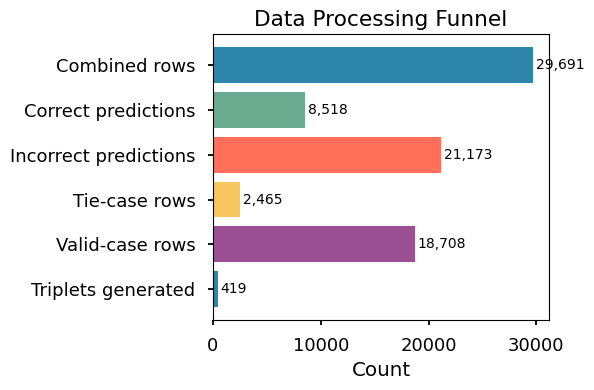

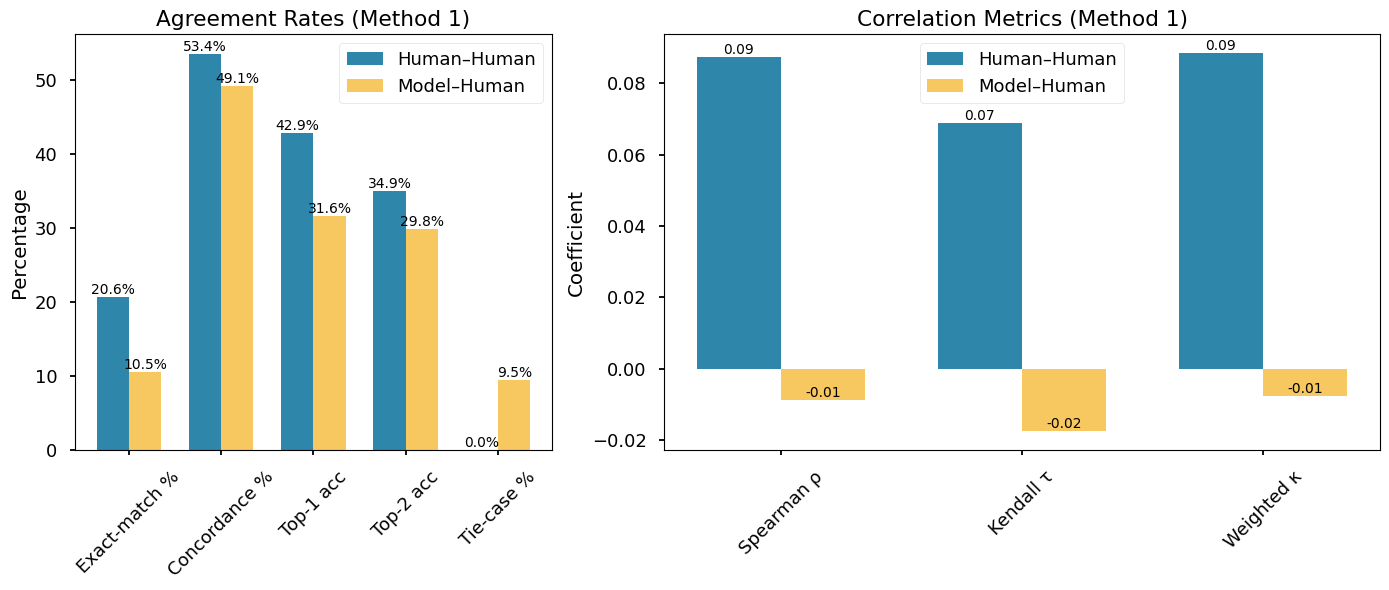

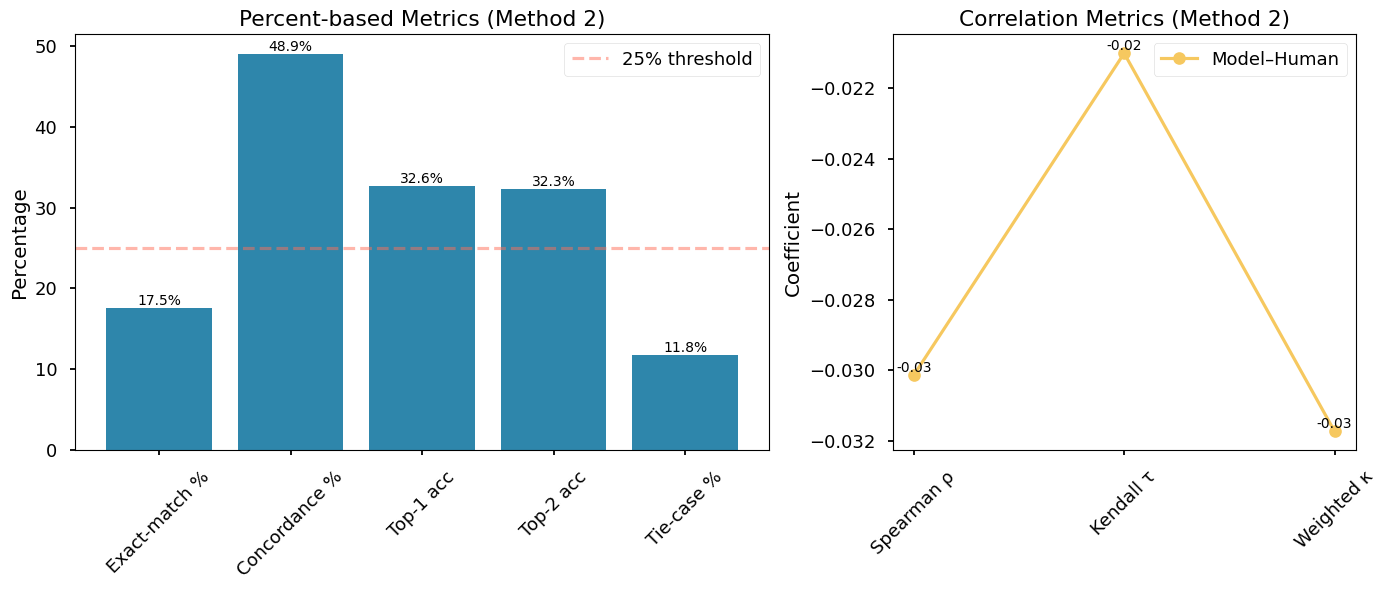

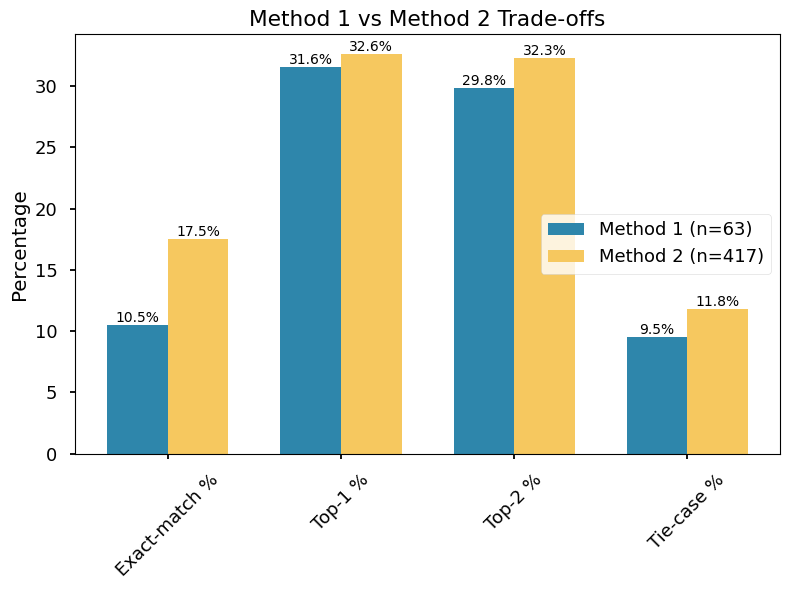

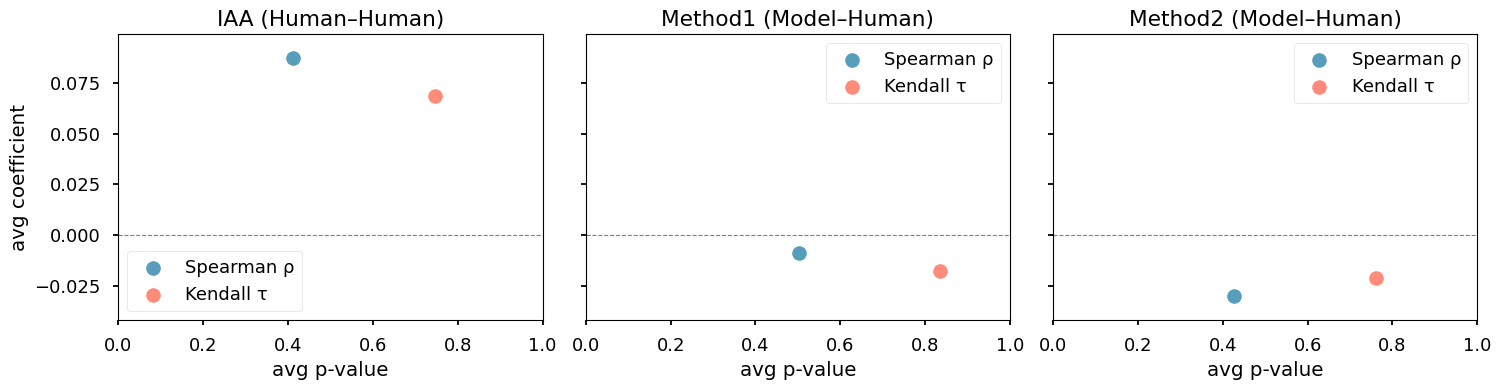

In [9]:
# Cell 8 - Visualizations

# Set style
plt.style.use('seaborn-v0_8-talk')
sns.set_palette('husl')

# Custom color palette
COLORS = {
    'blue': '#2E86AB',
    'yellow': '#F6C85F',
    'red': '#FF6F59',
    'green': '#6BAB90',
    'purple': '#9B5094'
}

def create_overall_metrics() -> pd.DataFrame:
    """
    Create a combined metrics DataFrame for visualization.

    Returns:
        DataFrame containing combined metrics from all methods
    """
    try:
        # Verify required DataFrames exist
        if any(df is None for df in [iaa_metrics, method1_results_df, method2_results_df]):
            raise ValueError("One or more required metric DataFrames are missing")

        # Get metrics with error checking
        iaa_metrics_dict = iaa_metrics.iloc[0].to_dict()
        method1_metrics_dict = method1_results_df.iloc[0].to_dict()
        method2_metrics_dict = method2_results_df.iloc[0].to_dict()

        # Combine all metrics with validation
        overall_metrics = {
            # IAA metrics
            'iaa_exact_match_pct': iaa_metrics_dict.get('exact_match_pct', 0.0),
            'iaa_pairwise_concordance': iaa_metrics_dict.get('avg_pairwise_concordance', 0.0),
            'iaa_top1_accuracy': iaa_metrics_dict.get('top1_accuracy', 0.0),
            'iaa_top2_accuracy': iaa_metrics_dict.get('top2_accuracy', 0.0),
            'iaa_tie_case_pct': iaa_metrics_dict.get('tie_case_pct', 0.0),
            'iaa_spearman_rho': iaa_metrics_dict.get('avg_spearman_rho', 0.0),
            'iaa_spearman_p':   iaa_metrics_dict.get('avg_spearman_p', 1.0),
            'iaa_kendall_tau': iaa_metrics_dict.get('avg_kendall_tau', 0.0),
            'iaa_kendall_p':    iaa_metrics_dict.get('avg_kendall_p', 1.0),
            'iaa_weighted_kappa': iaa_metrics_dict.get('avg_weighted_kappa', 0.0),

            # Method 1 metrics
            'method1_exact_match_pct': method1_metrics_dict.get('method1_exact_match_pct', 0.0),
            'method1_pairwise_concordance': method1_metrics_dict.get('method1_pairwise_concordance', 0.0),
            'method1_top1_accuracy': method1_metrics_dict.get('method1_top1_accuracy', 0.0),
            'method1_top2_accuracy': method1_metrics_dict.get('method1_top2_accuracy', 0.0),
            'method1_tie_case_pct': method1_metrics_dict.get('method1_tie_case_pct', 0.0),
            'method1_spearman_rho': method1_metrics_dict.get('method1_spearman_rho', 0.0),
            'method1_spearman_p':   method1_metrics_dict.get('method1_spearman_p', 1.0),
            'method1_kendall_tau': method1_metrics_dict.get('method1_kendall_tau', 0.0),
            'method1_kendall_p':    method1_metrics_dict.get('method1_kendall_p', 1.0),
            'method1_weighted_kappa': method1_metrics_dict.get('method1_weighted_kappa', 0.0),

            # Method 2 metrics
            'method2_exact_match_pct': method2_metrics_dict.get('method2_exact_match_pct', 0.0),
            'method2_pairwise_concordance': method2_metrics_dict.get('method2_pairwise_concordance', 0.0),
            'method2_top1_accuracy': method2_metrics_dict.get('method2_top1_accuracy', 0.0),
            'method2_top2_accuracy': method2_metrics_dict.get('method2_top2_accuracy', 0.0),
            'method2_tie_case_pct': method2_metrics_dict.get('method2_tie_case_pct', 0.0),
            'method2_spearman_rho': method2_metrics_dict.get('method2_spearman_rho', 0.0),
            'method2_spearman_p':   method2_metrics_dict.get('method2_spearman_p', 1.0),
            'method2_kendall_tau': method2_metrics_dict.get('method2_kendall_tau', 0.0),
            'method2_kendall_p':    method2_metrics_dict.get('method2_kendall_p', 1.0),
            'method2_weighted_kappa': method2_metrics_dict.get('method2_weighted_kappa', 0.0)
        }

        # Verify all values are numeric
        for k, v in overall_metrics.items():
            if not isinstance(v, (int, float)):
                logging.warning(f"Non-numeric value found for {k}: {v}")
                overall_metrics[k] = 0.0

        df = pd.DataFrame([overall_metrics])
        logging.info("✅ Successfully created overall metrics DataFrame")
        return df

    except Exception as e:
        logging.error(f"Error creating overall metrics: {str(e)}")
        return pd.DataFrame()

def plot_data_funnel(combined_df, correct_df, tie_df, valid_df, model_triplets_df):
    counts = {
        'Combined rows':           len(combined_df),
        'Correct predictions':     len(correct_df),
        'Incorrect predictions':   len(combined_df) - len(correct_df),
        'Tie-case rows':           len(tie_df),
        'Valid-case rows':         len(valid_df),
        'Triplets generated':      len(model_triplets_df)
    }
    stages, values = zip(*counts.items())
    # pick one color per bar, cycling through your palette
    palette_keys = ['blue','green','red','yellow','purple','blue']
    bar_colors = [COLORS[k] for k in palette_keys[:len(stages)]]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(stages, values, color=bar_colors)
    max_val = max(values)
    for i, v in enumerate(values):
        ax.text(v + max_val * 0.01, i, f"{v:,}", va='center')
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title("Data Processing Funnel")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "data_funnel.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig

def plot_human_vs_model_m1(overall_metrics_df: pd.DataFrame) -> plt.Figure:
    """
    Plot 1: Percent vs Correlation panels for Method 1 (n=63).

    Args:
        overall_metrics_df: DataFrame containing overall metrics

    Returns:
        matplotlib Figure object
    """
    # Prepare data
    pct_cols_h = [
        'iaa_exact_match_pct',
        'iaa_pairwise_concordance',
        'iaa_top1_accuracy',
        'iaa_top2_accuracy',
        'iaa_tie_case_pct'
    ]
    pct_cols_m = [
        'method1_exact_match_pct',
        'method1_pairwise_concordance',
        'method1_top1_accuracy',
        'method1_top2_accuracy',
        'method1_tie_case_pct'
    ]
    corr_cols_h = [
        'iaa_spearman_rho',
        'iaa_kendall_tau',
        'iaa_weighted_kappa'
    ]
    corr_cols_m = [
        'method1_spearman_rho',
        'method1_kendall_tau',
        'method1_weighted_kappa'
    ]

    # Ensure all values are numeric
    human_pct = [float(overall_metrics_df[c].iloc[0]) for c in pct_cols_h]
    model_pct = [float(overall_metrics_df[c].iloc[0]) for c in pct_cols_m]
    human_corr = [float(overall_metrics_df[c].iloc[0]) for c in corr_cols_h]
    model_corr = [float(overall_metrics_df[c].iloc[0]) for c in corr_cols_m]

    metrics_pct = ['Exact-match %', 'Concordance %', 'Top-1 acc', 'Top-2 acc', 'Tie-case %']
    metrics_corr = ['Spearman ρ', 'Kendall τ', 'Weighted κ']

    # Draw subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                  gridspec_kw={'width_ratios': [2, 3]})

    # A) Agreement Rates
    x1 = np.arange(len(metrics_pct))
    w = 0.35
    bars_h1 = ax1.bar(x1 - w/2, human_pct, w, color=COLORS['blue'], label='Human–Human')
    bars_m1 = ax1.bar(x1 + w/2, model_pct, w, color=COLORS['yellow'], label='Model–Human')
    ax1.set_xticks(x1)
    ax1.set_xticklabels(metrics_pct, rotation=45)
    ax1.set_ylabel('Percentage')
    ax1.set_title('Agreement Rates (Method 1)')
    for bar in bars_h1 + bars_m1:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%',
                ha='center', va='bottom')
    ax1.legend()

    # B) Correlation Metrics
    x2 = np.arange(len(metrics_corr))
    bars_h2 = ax2.bar(x2 - w/2, human_corr, w, color=COLORS['blue'], label='Human–Human')
    bars_m2 = ax2.bar(x2 + w/2, model_corr, w, color=COLORS['yellow'], label='Model–Human')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(metrics_corr, rotation=45)
    ax2.set_ylabel('Coefficient')
    ax2.set_title('Correlation Metrics (Method 1)')
    for bar in bars_h2 + bars_m2:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
                ha='center', va='bottom')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return fig

def plot_model_performance_m2(overall_metrics_df: pd.DataFrame) -> plt.Figure:
    """
    Plot 2: Percent vs Correlation panels for Method 2 (n=417).

    Args:
        overall_metrics_df: DataFrame containing overall metrics

    Returns:
        matplotlib Figure object
    """
    pct_cols = [
        'method2_exact_match_pct',
        'method2_pairwise_concordance',
        'method2_top1_accuracy',
        'method2_top2_accuracy',
        'method2_tie_case_pct'
    ]
    corr_cols = [
        'method2_spearman_rho',
        'method2_kendall_tau',
        'method2_weighted_kappa'
    ]

    # Ensure all values are numeric
    vals_pct = [float(overall_metrics_df[c].iloc[0]) for c in pct_cols]
    vals_corr = [float(overall_metrics_df[c].iloc[0]) for c in corr_cols]

    metrics_pct = ['Exact-match %', 'Concordance %', 'Top-1 acc', 'Top-2 acc', 'Tie-case %']
    metrics_corr = ['Spearman ρ', 'Kendall τ', 'Weighted κ']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                  gridspec_kw={'width_ratios': [3, 2]})

    # A) Percent-based Metrics
    x1 = np.arange(len(metrics_pct))
    w = 0.5
    bars = ax1.bar(x1, vals_pct, color=COLORS['blue'])
    ax1.axhline(25, color=COLORS['red'], linestyle='--', alpha=0.5, label='25% threshold')
    ax1.set_xticks(x1)
    ax1.set_xticklabels(metrics_pct, rotation=45)
    ax1.set_ylabel('Percentage')
    ax1.set_title('Percent-based Metrics (Method 2)')
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%',
                ha='center', va='bottom')
    ax1.legend()

    # B) Correlation Metrics (dot plot)
    x2 = np.arange(len(metrics_corr))
    ax2.plot(x2, vals_corr, 'o-', color=COLORS['yellow'], label='Model–Human')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(metrics_corr, rotation=45)
    ax2.set_ylabel('Coefficient')
    ax2.set_title('Correlation Metrics (Method 2)')
    for i, v in enumerate(vals_corr):
        ax2.text(x2[i], v, f'{v:.2f}', ha='center', va='bottom')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return fig

def plot_method_comparison(overall_metrics_df: pd.DataFrame) -> plt.Figure:
    """
    Plot 3: Method 1 vs Method 2 Trade-offs (percent-only).

    Args:
        overall_metrics_df: DataFrame containing overall metrics

    Returns:
        matplotlib Figure object
    """
    metrics = ['Exact-match %', 'Top-1 %', 'Top-2 %', 'Tie-case %']
    m1_cols = [
        'method1_exact_match_pct',
        'method1_top1_accuracy',
        'method1_top2_accuracy',
        'method1_tie_case_pct'
    ]
    m2_cols = [
        'method2_exact_match_pct',
        'method2_top1_accuracy',
        'method2_top2_accuracy',
        'method2_tie_case_pct'
    ]

    # Ensure all values are numeric
    m1 = [float(overall_metrics_df[c].iloc[0]) for c in m1_cols]
    m2 = [float(overall_metrics_df[c].iloc[0]) for c in m2_cols]

    x = np.arange(len(metrics))
    w = 0.35
    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.bar(x - w/2, m1, w, color=COLORS['blue'], label='Method 1 (n=63)')
    bars2 = ax.bar(x + w/2, m2, w, color=COLORS['yellow'], label='Method 2 (n=417)')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45)
    ax.set_ylabel('Percentage')
    ax.set_title('Method 1 vs Method 2 Trade-offs')
    for bar in bars1 + bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%',
                ha='center', va='bottom')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig


def plot_avg_corr_p_scatter(overall_metrics_df: pd.DataFrame):
    om = overall_metrics_df.iloc[0]
    panels = [
      ("IAA (Human–Human)",
       "iaa_spearman_p", "iaa_spearman_rho",
       "iaa_kendall_p",  "iaa_kendall_tau"),
      ("Method1 (Model–Human)",
       "method1_spearman_p", "method1_spearman_rho",
       "method1_kendall_p",  "method1_kendall_tau"),
      ("Method2 (Model–Human)",
       "method2_spearman_p", "method2_spearman_rho",
       "method2_kendall_p",  "method2_kendall_tau"),
    ]

    # 1) compute y‐limits dynamically
    coeffs = []
    for _, _, sp_r, _, kt_r in panels:
        coeffs.extend([om[sp_r], om[kt_r]])
    min_c, max_c = min(coeffs), max(coeffs)
    pad = (max_c - min_c) * 0.1
    ymin, ymax = min_c - pad, max_c + pad

    # 2) build the grid
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, (title, sp_p, sp_r, kt_p, kt_r) in zip(axes, panels):
        ax.scatter(om[sp_p], om[sp_r],
                   s=100, alpha=0.8,
                   color=COLORS['blue'], label="Spearman ρ")
        ax.scatter(om[kt_p], om[kt_r],
                   s=100, alpha=0.8,
                   color=COLORS['red'],  label="Kendall τ")

        ax.set_title(title)
        ax.set_xlabel("avg p-value")
        if ax is axes[0]:
            ax.set_ylabel("avg coefficient")
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xlim(0, 1)
        ax.set_ylim(ymin, ymax)            # ← use dynamic limits here
        ax.legend()

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, "avg_corr_vs_p_scatter.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig




# Create overall metrics DataFrame
overall_metrics_df = create_overall_metrics()


# Generate plots
plots = {
    'funnel_fig'           : plot_data_funnel(combined_df, correct_df, tie_df, valid_df, model_triplets_df),
    'human_vs_model_m1'    : plot_human_vs_model_m1(overall_metrics_df),
    'model_performance_m2' : plot_model_performance_m2(overall_metrics_df),
    'method_comparison'    : plot_method_comparison(overall_metrics_df),
    'avg_corr_vs_p_scatter': plot_avg_corr_p_scatter(overall_metrics_df)
}

# Save plots
for name, fig in plots.items():
    fig.savefig(os.path.join(OUTPUT_DIR, f'{name}.png'), dpi=300, bbox_inches='tight')
    plt.close(fig)

logging.info("✅ Visualizations saved to output directory")

